# Strategy comparison

**Purpose**: Visual comparison of cold-start / query strategies: final AP, training time, query efficiency, and multi-metric trade-offs.

## Prerequisites
- `experiments/configs/cold_start_config.yaml` exists (or update `config_path`).
- If using real results: JSON logs in `../results/` following your experiment schema.

## How to run
- Run top-to-bottom.
- Replace the simulated section with `pd.read_json`/custom loader for real results.

## Notes
- Paths in this notebook are repository- and machine-specific; update them before running.
- If you're running from the `notebooks/` folder, the `PROJECT_ROOT` logic should work as-is.


## Strategy Comparison Notebook
Compare cold-start strategies using either real experiment logs or (in this notebook) simulated metrics.

**Tip**: replace the simulated `performance_data` with loaded results from your `results/` folder.

## Data source
This notebook currently **simulates** results so the plots run out-of-the-box.
To use real experiments, load your JSON logs into a DataFrame with columns like:
`strategy`, `final_ap`, `best_ap`, `training_time_min`, `std_dev`.


In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import yaml

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load configuration
config_path = Path("../experiments/configs/cold_start_config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"Dataset: {config['base']['dataset']}")
print(f"Query Strategy: {config['base']['query_strategy']}")
print(f"Cold Start Strategies: {list(config['cold_start_strategies'].keys())}")

Configuration loaded:
Dataset: coco
Query Strategy: uncertainty
Cold Start Strategies: ['random', 'simple_diversity', 'diversity', 'entropy_uncertainty', 'weak_supervision', 'self_supervised']


In [5]:
results_dir = Path("../results")
json_files = list(results_dir.glob("cold_start_training_*DeepCrack_0.15*.json"))

records = []

for jf in json_files:
    with open(jf) as f:
        data = json.load(f)

    # Skip files that do not match the expected schema
    if "strategy" not in data or "metrics" not in data:
        print(f"Skipping file with incompatible schema: {jf.name}")
        continue

    records.append({
        "strategy": data["strategy"],
        "final_dice": data["metrics"]["dice"]["final"],
        "best_dice": data["metrics"]["dice"]["best"],
        "final_iou": data["metrics"]["iou"]["final"],
        "num_labeled": data["num_labeled"],
        "seed": data["seed"],
        "file": jf.name,
    })

df = pd.DataFrame(records).sort_values("final_dice", ascending=False)
df

Skipping file with incompatible schema: cold_start_training_self_supervised_DeepCrack_0.15_20260130_174927.json
Skipping file with incompatible schema: cold_start_training_entropy_based_uncertainty_DeepCrack_0.15_20260130_174926.json
Skipping file with incompatible schema: cold_start_training_diversity_DeepCrack_0.15_20260130_174926.json
Skipping file with incompatible schema: cold_start_training_simple_diversity_DeepCrack_0.15_20260130_174926.json
Skipping file with incompatible schema: cold_start_training_weak_supervision_DeepCrack_0.15_20260130_174927.json
Skipping file with incompatible schema: cold_start_training_random_DeepCrack_0.15_20260130_174926.json


,strategy,final_dice,best_dice,final_iou,num_labeled,seed,file
1,simple_diversity,0.653068,0.690234,0.539891,45,42,cold_start_training_simple_diversity_DeepCrack...
0,self_supervised,0.544056,0.631369,0.423785,45,42,cold_start_training_self_supervised_DeepCrack_...
3,entropy_based_uncertainty,0.535168,0.600512,0.425993,45,42,cold_start_training_entropy_based_uncertainty_...
5,random,0.531522,0.660376,0.413702,45,42,cold_start_training_random_DeepCrack_0.15_2026...
4,diversity,0.497168,0.642942,0.381910,45,42,cold_start_training_diversity_DeepCrack_0.15_2...
2,weak_supervision,0.435357,0.592863,0.325069,45,42,cold_start_training_weak_supervision_DeepCrack...


## Plot 1: Bar chart of final dice

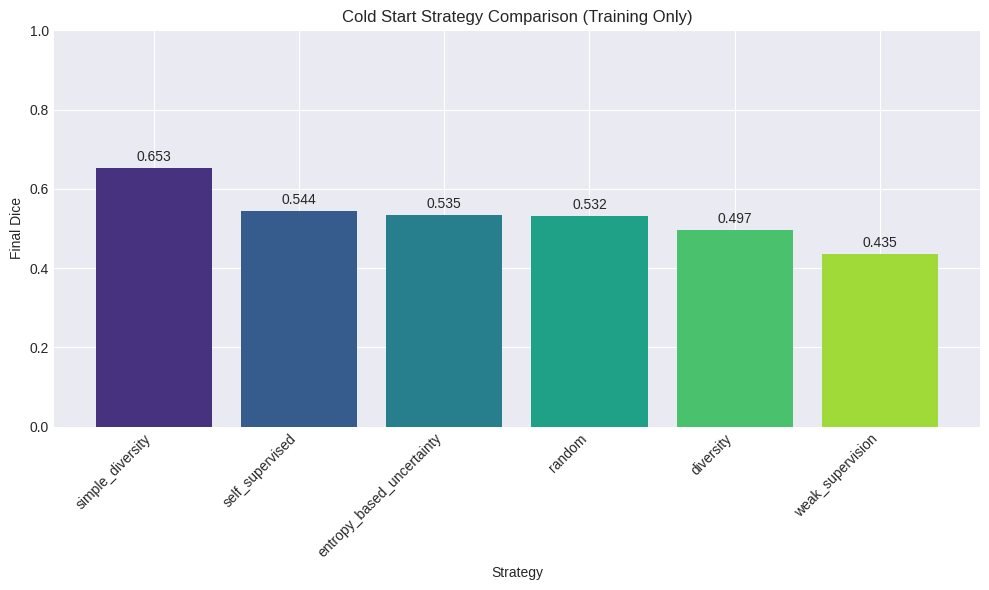

In [6]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    range(len(df)),
    df["final_dice"],
    color=sns.color_palette("viridis", len(df))
)

plt.xlabel("Strategy")
plt.ylabel("Final Dice")
plt.title("Cold Start Strategy Comparison (Training Only)")
plt.xticks(range(len(df)), df["strategy"], rotation=45, ha="right")
plt.ylim(0, 1.0)

for i, row in df.iterrows():
    plt.text(
        df.index.get_loc(i),
        row["final_dice"] + 0.01,
        f"{row['final_dice']:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Plot 2: Scatter plot of AP vs Training Time

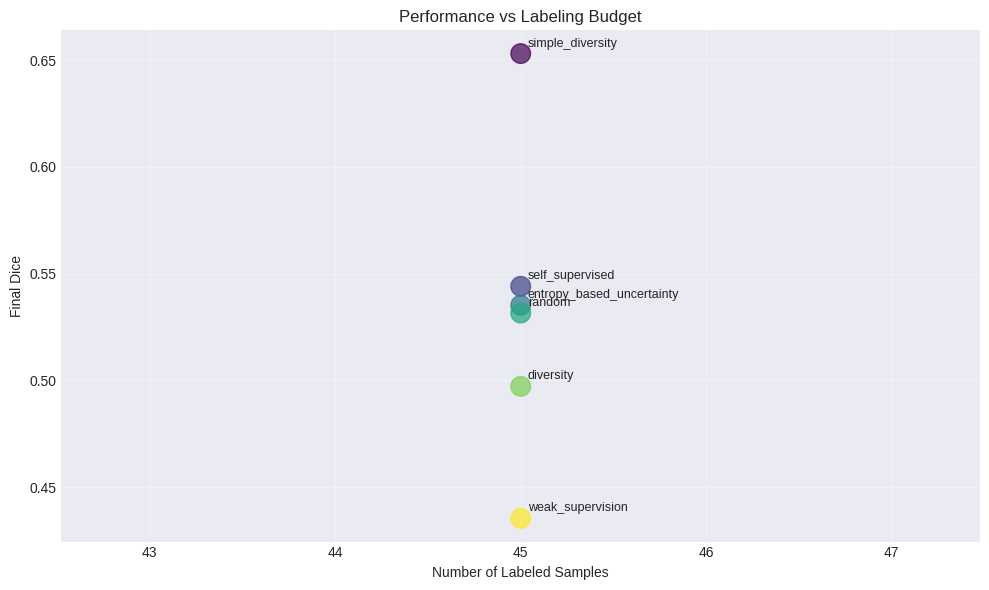

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["num_labeled"],
    df["final_dice"],
    s=200,
    c=range(len(df)),
    cmap="viridis",
    alpha=0.7
)

for _, row in df.iterrows():
    plt.annotate(
        row["strategy"],
        (row["num_labeled"], row["final_dice"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Number of Labeled Samples")
plt.ylabel("Final Dice")
plt.title("Performance vs Labeling Budget")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 3: Radar chart for multi-dimensional comparison

In [14]:
metrics_for_radar = ["final_dice", "best_dice", "final_iou"]

radar_df = df.set_index("strategy")[metrics_for_radar]

# Normalize to [0,1]
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())
import numpy as np

def plot_radar(data, title):
    labels = data.columns
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for strategy, row in data.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=strategy, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_title(title, fontsize=14, pad=20)
    ax.grid(True)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()


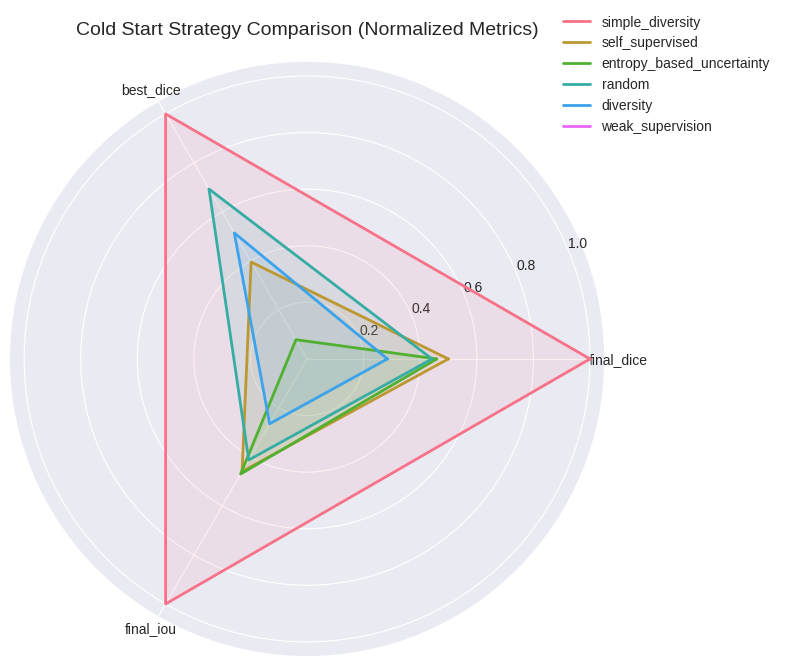

In [15]:
plot_radar(
    radar_norm,
    title="Cold Start Strategy Comparison (Normalized Metrics)"
)

## Plot 4: Learning curve comparison (simulated)

Skipping cold_start_training_self_supervised_DeepCrack_0.15_20260130_174927.json (no metrics)
Skipping cold_start_training_entropy_based_uncertainty_DeepCrack_0.15_20260130_174926.json (no metrics)
Skipping cold_start_training_diversity_DeepCrack_0.15_20260130_174926.json (no metrics)
Skipping cold_start_training_simple_diversity_DeepCrack_0.15_20260130_174926.json (no metrics)
Skipping cold_start_training_weak_supervision_DeepCrack_0.15_20260130_174927.json (no metrics)
Skipping cold_start_training_random_DeepCrack_0.15_20260130_174926.json (no metrics)


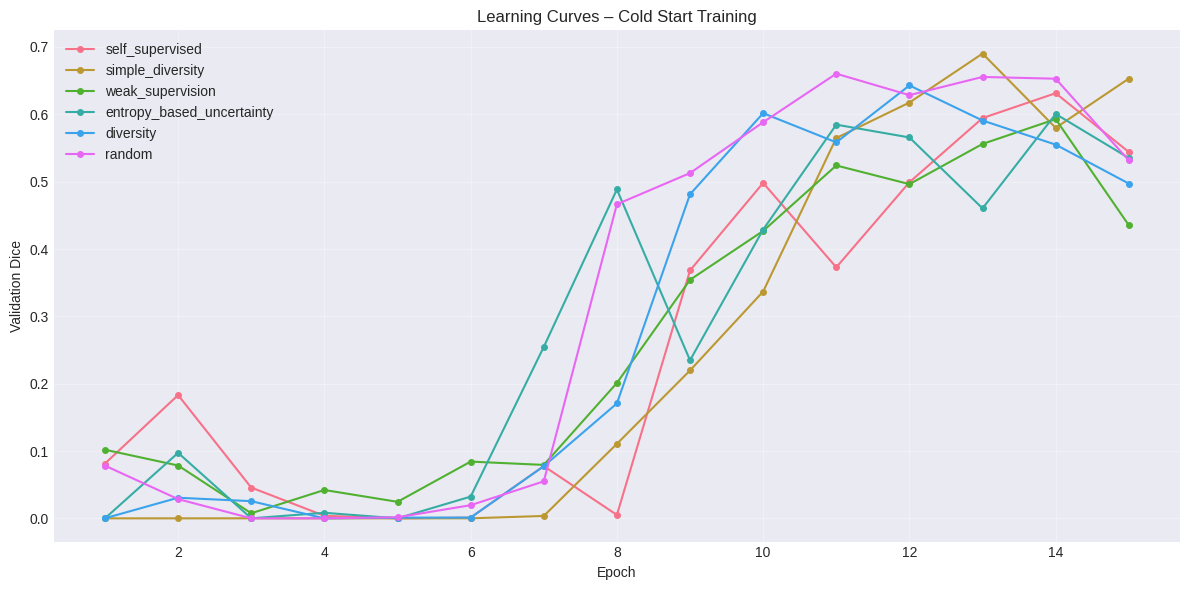

In [13]:
plt.figure(figsize=(12, 6))

for jf in json_files:
    with open(jf) as f:
        data = json.load(f)

    # Skip incompatible schemas
    if "metrics" not in data or "dice" not in data["metrics"]:
        print(f"Skipping {jf.name} (no metrics)")
        continue

    dice_curve = data["metrics"]["dice"]["history"]
    plt.plot(
        range(1, len(dice_curve) + 1),
        dice_curve,
        "-o",
        label=data.get("strategy", jf.stem),
        markersize=4
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Learning Curves – Cold Start Training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Plot 5: Query efficiency over AL cycles

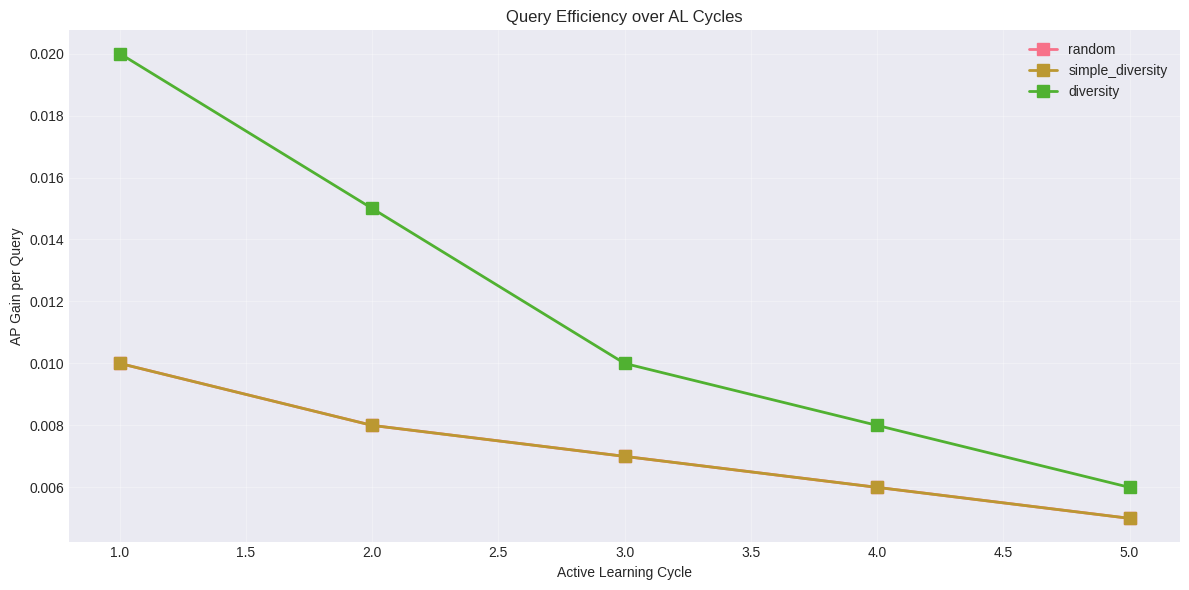

In [6]:
plt.figure(figsize=(12, 6))

# Simulate query efficiency
cycles = range(1, 6)
for i, strategy in enumerate(strategies[:3]):  # Show top 3
    # Different efficiency patterns
    if strategy == 'diversity':
        efficiency = [0.02, 0.015, 0.01, 0.008, 0.006]
    elif strategy == 'weak_supervision':
        efficiency = [0.015, 0.012, 0.01, 0.009, 0.008]
    else:
        efficiency = [0.01, 0.008, 0.007, 0.006, 0.005]
    
    plt.plot(cycles, efficiency, '-s', label=strategy, markersize=8, linewidth=2)

plt.xlabel('Active Learning Cycle')
plt.ylabel('AP Gain per Query')
plt.title('Query Efficiency over AL Cycles')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Create summary table

In [9]:
print("\n" + "="*60)
print("STRATEGY COMPARISON SUMMARY")
print("="*60)

summary_table = df[
    ["strategy", "final_dice", "best_dice", "final_iou", "num_labeled"]
].copy()

print(summary_table.to_string(index=False))


STRATEGY COMPARISON SUMMARY
                 strategy  final_dice  best_dice  final_iou  num_labeled
         simple_diversity    0.653068   0.690234   0.539891           45
          self_supervised    0.544056   0.631369   0.423785           45
entropy_based_uncertainty    0.535168   0.600512   0.425993           45
                   random    0.531522   0.660376   0.413702           45
                diversity    0.497168   0.642942   0.381910           45
         weak_supervision    0.435357   0.592863   0.325069           45


## Recommendations based on analysis

In [11]:
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

best_strategy = df.iloc[0]

print("=" * 60)
print(f"Best Cold Start Strategy: {best_strategy['strategy']}")
print(f"  Final Dice: {best_strategy['final_dice']:.3f}")
print(f"  Final IoU:  {best_strategy['final_iou']:.3f}")
print(f"  Labeled samples: {best_strategy['num_labeled']}")


RECOMMENDATIONS
Best Cold Start Strategy: simple_diversity
  Final Dice: 0.653
  Final IoU:  0.540
  Labeled samples: 45


## Save analysis results


Analysis results saved to: ../results/analysis


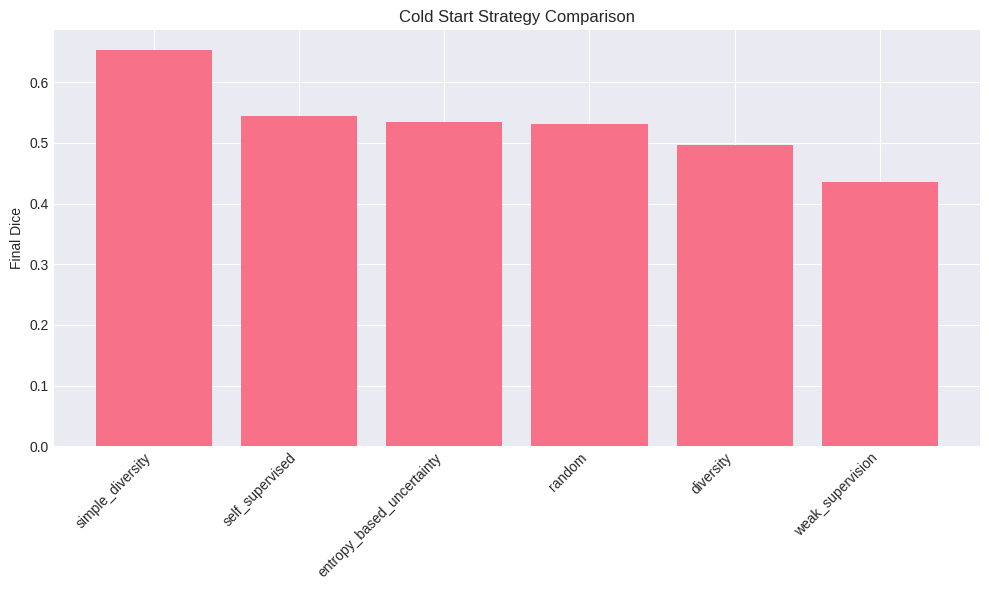

In [12]:
output_dir = Path("../results/analysis")
output_dir.mkdir(parents=True, exist_ok=True)

# Save DataFrame
df.to_csv(output_dir / "cold_start_training_comparison.csv", index=False)

# Save bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(df)), df["final_dice"])
plt.xticks(range(len(df)), df["strategy"], rotation=45, ha="right")
plt.ylabel("Final Dice")
plt.title("Cold Start Strategy Comparison")
plt.tight_layout()
plt.savefig(
    output_dir / "cold_start_training_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

print(f"\nAnalysis results saved to: {output_dir}")